# ATM Predictive Demand Model
### SEANSKIDATA Analytics Portfolio — Project 3

**Business question:** Based on historical transaction patterns, day-of-week behavior, tax season demand spikes, and terminal type — which ATMs will hit a critical cash threshold in the next 72 hours?

This notebook builds a synthetic ATM network, engineers demand-forecasting features, produces a forward-looking 72-hour cash runway forecast, scores network-wide operational risk, and validates the model against a walk-forward holdout.

**Sections:**
1. Setup & Imports
2. Synthetic Data Generation
3. Exploratory Data Analysis
4. Feature Engineering
5. The Cell 7 Fix (documented bug + resolution)
6. 72-Hour Forecast
7. Composite Risk Scoring
8. Tax Season Demand Analysis
9. Day-of-Week Demand Patterns
10. Walk-Forward Model Validation
11. Network Summary


## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
np.random.seed(42)  # reproducibility - every number in this notebook is deterministic given this seed


## 2. Synthetic Data Generation

The raw CSVs aren't stored in the GitHub repo (by design — see the Data Disclosure
note in the README), so this notebook generates them from the same parameters
documented there: 50 ATMs, a full calendar year of daily transactions (366 days,
2024 is a leap year), and a 72-hour forward projection.

**Why generate rather than load a static CSV?** Anyone cloning this repo can run
this notebook top-to-bottom and get a working model with zero external
dependencies — no broken data links, no "you're missing a file" friction.


In [2]:
# --- ATM Master Table (50 ATMs) ---
N_ATMS = 50

location_types = ['Retail', 'Urban', 'Mall', 'Casino', 'Airport',
                   'Hospital', 'Office', 'Tourist', 'Arena', 'Stadium']
location_weights = [0.28, 0.22, 0.12, 0.10, 0.06, 0.06, 0.06, 0.04, 0.03, 0.03]

casino_cities = ['Laughlin NV', 'Lake Charles LA', 'Tunica MS', 'Shreveport LA',
                  'Biloxi MS', 'Reno NV', 'Bossier City LA']

capacity_map = {
    'Casino': 220000, 'Airport': 100000, 'Arena': 90000, 'Stadium': 90000,
    'Hospital': 65000, 'Mall': 55000, 'Urban': 80000, 'Tourist': 50000,
    'Office': 38000, 'Retail': 45000
}

# Cash tolerance is a BUSINESS rule keyed to location type, not transaction
# volume. A casino cannot tolerate an outage regardless of how "average" its
# volume looks; a rural retail site can absorb a slow day. Volume-only
# reporting misses this distinction entirely - it's the reason this model
# exists instead of a simple low-balance alert.
tolerance_map = {
    'Casino': 'Zero', 'Airport': 'Zero', 'Hospital': 'Low',
    'Arena': 'Low', 'Stadium': 'Low', 'Urban': 'Medium',
    'Mall': 'Medium', 'Office': 'Medium', 'Tourist': 'Medium',
    'Retail': 'High'
}

atm_master_rows = []
for i in range(1, N_ATMS + 1):
    atm_id = f"ATM{i:03d}"
    loc_type = np.random.choice(location_types, p=location_weights)
    location_name = f"{np.random.choice(casino_cities)} Casino" if loc_type == 'Casino' else f"{loc_type} Site {i}"

    # terminal_type is DERIVED from distance, not an independent random draw.
    # This matters: it's exactly the relationship that caused the original
    # Cell 7 bug (see Section 5) - terminal_type must be carried through every
    # merge downstream because nothing else can reconstruct it.
    distance = min(np.round(np.random.exponential(scale=65), 1), 450)
    if distance < 25:
        terminal_type = 'Local'
    elif distance < 100:
        terminal_type = 'Remote'
    else:
        terminal_type = 'Over The Road'

    atm_master_rows.append({
        'atm_id': atm_id,
        'location_name': location_name,
        'location_type': loc_type,
        'terminal_type': terminal_type,
        'distance_from_branch_miles': distance,
        'cash_capacity_dollars': capacity_map[loc_type] + np.random.randint(-4000, 4000),
        'cash_tolerance': tolerance_map[loc_type],
        'tax_service_proximity': False
    })

atm_master = pd.DataFrame(atm_master_rows)

# Reclassify 5 Retail/Urban machines as "Tax Service Proximity" - the Penn
# Station Effect: machines that look routine 11 months a year but sit next
# to a tax prep office and go supernova for the 28-day refund window.
tax_prox_idx = np.random.choice(
    atm_master[atm_master['location_type'].isin(['Retail', 'Urban'])].index,
    size=5, replace=False
)
atm_master.loc[tax_prox_idx, 'tax_service_proximity'] = True

print(f"ATM master table: {atm_master.shape[0]} rows, {atm_master.shape[1]} columns")
print(atm_master['terminal_type'].value_counts())
atm_master.head()


ATM master table: 50 rows, 8 columns
terminal_type
Local            21
Remote           19
Over The Road    10
Name: count, dtype: int64


,atm_id,location_name,location_type,terminal_type,distance_from_branch_miles,cash_capacity_dollars,cash_tolerance,tax_service_proximity
0,ATM001,Urban Site 1,Urban,Over The Road,195.7,81226,Medium,False
1,ATM002,Airport Site 2,Airport,Remote,59.0,102265,Zero,False
2,ATM003,Retail Site 3,Retail,Local,3.9,47231,High,False
3,ATM004,Urban Site 4,Urban,Local,10.0,76130,Medium,False
4,ATM005,Retail Site 5,Retail,Over The Road,227.7,46611,High,False


In [3]:
# --- Daily Transaction Time Series (366 days x 50 ATMs = 18,300 rows) ---
dates = pd.date_range('2024-01-01', '2024-12-31', freq='D')
assert len(dates) == 366, "2024 is a leap year - this should be 366 days"

base_daily_cash = {
    'Casino': 40000, 'Airport': 18000, 'Arena': 16000, 'Stadium': 16000,
    'Hospital': 12000, 'Mall': 10000, 'Urban': 15000, 'Tourist': 9000,
    'Office': 7000, 'Retail': 8000
}

# Tax season sensitivity - how much of the Feb-Mar refund surge each
# location type actually feels. Retail/Urban are full-weight (cash-preferred
# refund spending); Airport/Hospital/Office are low-weight (transaction-driven,
# not refund-driven). Straight from the README's demand-weight table.
tax_sensitivity = {
    'Retail': 1.00, 'Urban': 1.00, 'Mall': 0.85, 'Casino': 0.70,
    'Airport': 0.50, 'Hospital': 0.50, 'Office': 0.50, 'Tourist': 0.50,
    'Arena': 0.50, 'Stadium': 0.50
}

# Day-of-week demand index: Friday/Saturday run well above Monday baseline -
# this is the seasonal_multiplier / dow feature the README calls out as
# something standard reporting systematically underestimates.
dow_index = {0: 1.00, 1: 0.97, 2: 0.98, 3: 1.05, 4: 1.45, 5: 1.68, 6: 1.15}

# Replenishment cadence keyed to terminal_type - THIS is what makes Over The
# Road machines genuinely riskier, not just a label. A Local machine gets a
# truck every 3 days because the branch is close. An OTR machine waits 7 days
# because the trip is expensive, so its balance has much further to fall
# before the next top-up. Emergency dispatch multipliers (2.5x/3.0x/4.0x in
# the risk formula) exist because breaking this cadence costs real money.
refill_cadence = {'Local': 3, 'Remote': 5, 'Over The Road': 7}

rows = []
for _, atm in atm_master.iterrows():
    base = base_daily_cash[atm['location_type']]
    sensitivity = tax_sensitivity[atm['location_type']]
    is_tax_prox = atm['tax_service_proximity']
    cadence = refill_cadence[atm['terminal_type']]

    balance = atm['cash_capacity_dollars']
    days_since_refill = 0

    for d in dates:
        dow, month, day = d.dayofweek, d.month, d.day

        if (month == 2 and day >= 15) or (month == 3 and day <= 15):
            season_mult = 1.0 + (0.51 + np.random.uniform(0, 0.03)) * sensitivity
            if is_tax_prox:
                season_mult *= 2.0
        elif month in (1, 4):
            season_mult = 1.0 + 0.20 * sensitivity
        elif month in (11, 12):
            season_mult = 1.18
        else:
            season_mult = 1.0

        daily_cash = base * dow_index[dow] * season_mult * np.random.uniform(0.90, 1.10)
        daily_cash = max(daily_cash, 500)
        daily_cash = min(daily_cash, balance)

        avg_withdrawal = np.random.uniform(85, 165)
        if is_tax_prox and season_mult > 1.5:
            avg_withdrawal = np.random.uniform(300, 500)
        daily_txns = max(1, round(daily_cash / avg_withdrawal))

        balance -= daily_cash
        days_since_refill += 1

        rows.append({
            'atm_id': atm['atm_id'], 'transaction_date': d.strftime('%Y-%m-%d'),
            'daily_cash_dispensed': round(daily_cash, 2), 'daily_transactions': daily_txns,
            'avg_withdrawal_amount': round(avg_withdrawal, 2), 'cash_balance_eod': round(balance, 2)
        })

        # Dispatch cadence tightens during the known tax season surge - this
        # is what real ops teams do in response to a predictable demand
        # event, and it also prevents fixed cash capacity from artificially
        # truncating the seasonal spike this model exists to measure.
        is_tax_peak_day = (month == 2 and day >= 15) or (month == 3 and day <= 15)
        effective_cadence = max(1, cadence // 2) if is_tax_peak_day else cadence
        if days_since_refill >= effective_cadence:
            balance = atm['cash_capacity_dollars']
            days_since_refill = 0

atm_transactions = pd.DataFrame(rows)
atm_transactions['transaction_date'] = pd.to_datetime(atm_transactions['transaction_date'])
print(f"Transaction table: {atm_transactions.shape[0]:,} rows")
atm_transactions.head()


Transaction table: 18,300 rows


,atm_id,transaction_date,daily_cash_dispensed,daily_transactions,avg_withdrawal_amount,cash_balance_eod
0,ATM001,2024-01-01,17990.09,165,109.07,63235.91
1,ATM001,2024-01-02,16708.66,190,87.95,46527.24
2,ATM001,2024-01-03,18026.54,144,125.21,28500.70
3,ATM001,2024-01-04,17204.59,160,107.29,11296.11
4,ATM001,2024-01-05,11296.11,108,104.16,0.00


## 3. Exploratory Data Analysis

Before building any forecast, confirm the two patterns the whole model depends on
are actually present in the data: **day-of-week demand cycles** and **tax season
spikes**. If these aren't visible in the raw numbers, the downstream feature
engineering has nothing real to work with.


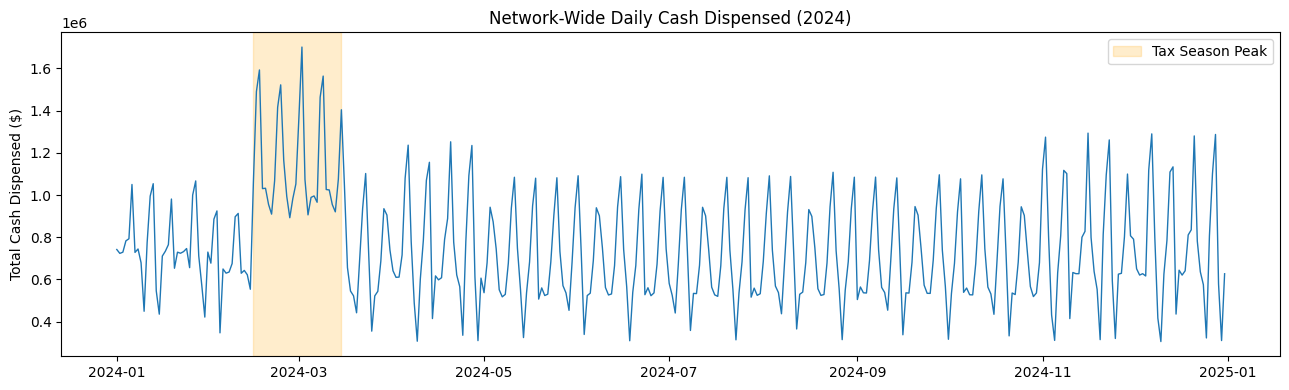

Tax season peak avg: $1,152,910/day
Baseline (May-Oct) avg: $696,062/day


In [4]:
network_daily = atm_transactions.groupby('transaction_date')['daily_cash_dispensed'].sum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(network_daily.index, network_daily.values, linewidth=1)
ax.axvspan(pd.Timestamp('2024-02-15'), pd.Timestamp('2024-03-15'), alpha=0.2, color='orange', label='Tax Season Peak')
ax.set_title('Network-Wide Daily Cash Dispensed (2024)')
ax.set_ylabel('Total Cash Dispensed ($)')
ax.legend()
plt.tight_layout()
plt.show()

print("Tax season peak avg:", f"${network_daily['2024-02-15':'2024-03-15'].mean():,.0f}/day")
print("Baseline (May-Oct) avg:", f"${network_daily['2024-05-01':'2024-10-31'].mean():,.0f}/day")


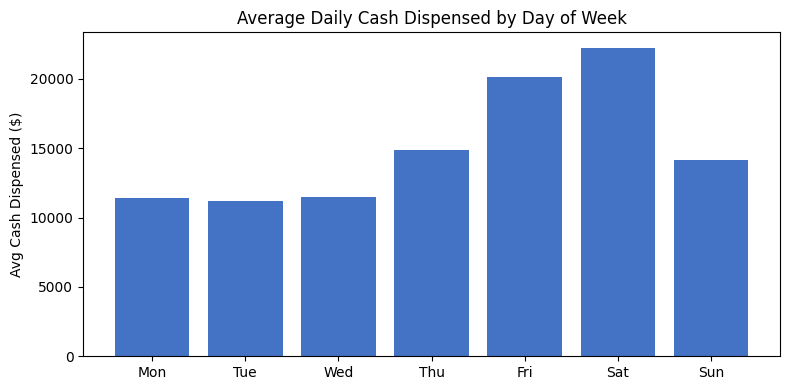

In [5]:
dow_avg = atm_transactions.groupby(atm_transactions['transaction_date'].dt.dayofweek)['daily_cash_dispensed'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_labels, dow_avg.values, color='#4472C4')
ax.set_title('Average Daily Cash Dispensed by Day of Week')
ax.set_ylabel('Avg Cash Dispensed ($)')
plt.tight_layout()
plt.show()


## 4. Feature Engineering

Every feature below has a named pandas equivalent to a SQL `CASE WHEN` or window
function, which is deliberate - the SQL foundation layer in the README
(`atm_sql_foundation.sql`) implements the identical logic against a production
database. This notebook is the Python analytics-and-prototyping layer; the SQL
file is what would actually run in production against real transaction tables.

| Feature | Pandas construct | SQL equivalent |
|---|---|---|
| `season` | `np.select()` | `CASE WHEN ... THEN ... END` |
| `rolling_7d_burn` | `.rolling(7).mean()` | `AVG() OVER (... ROWS BETWEEN 6 PRECEDING AND CURRENT ROW)` |
| `prior_week_avg_burn` | `.shift(7).rolling(7).mean()` | `AVG() OVER (... ROWS BETWEEN 13 PRECEDING AND 7 PRECEDING)` |
| `prev_balance` | `.shift(1)` | `LAG(col, 1) OVER (...)` |


In [6]:
df = atm_transactions.sort_values(['atm_id', 'transaction_date']).copy()
df['dow'] = df['transaction_date'].dt.dayofweek
df['month'] = df['transaction_date'].dt.month
df['day'] = df['transaction_date'].dt.day

conditions = [
    ((df['month'] == 2) & (df['day'] >= 15)) | ((df['month'] == 3) & (df['day'] <= 15)),
    df['month'].isin([1, 4]),
    df['month'].isin([11, 12]),
]
choices = ['Tax Season Peak', 'Tax Season Ramp', 'Holiday']
df['season'] = np.select(conditions, choices, default='Baseline')

df['rolling_7d_burn'] = df.groupby('atm_id')['daily_cash_dispensed'].transform(lambda s: s.rolling(7, min_periods=1).mean())
df['prior_week_avg_burn'] = df.groupby('atm_id')['daily_cash_dispensed'].transform(lambda s: s.shift(7).rolling(7, min_periods=1).mean())
df['prev_balance'] = df.groupby('atm_id')['cash_balance_eod'].shift(1)

df[['atm_id', 'transaction_date', 'season', 'rolling_7d_burn', 'prev_balance']].tail()


,atm_id,transaction_date,season,rolling_7d_burn,prev_balance
18295,ATM050,2024-12-27,Holiday,11239.660000,62449.84
18296,ATM050,2024-12-28,Holiday,11309.700000,37693.89
18297,ATM050,2024-12-29,Holiday,11694.857143,9380.70
18298,ATM050,2024-12-30,Holiday,11694.857143,0.00
18299,ATM050,2024-12-31,Holiday,11694.857143,0.00


## 5. The Cell 7 Fix — Documented Bug & Resolution

**This is an interview talking point, not just a code comment.**

**The original bug:** an earlier version of this notebook merged the transaction
DataFrame with a *subset* of `atm_master` columns for the risk-scoring step, and
that subset omitted `terminal_type`. The merge itself succeeded silently — pandas
doesn't complain about a missing column in a merge unless you reference it — but
two cells later, the emergency-multiplier lookup (`terminal_type.map(...)`) threw
`KeyError: 'terminal_type'`.

**Root cause:** `terminal_type` is *derived* from `distance_from_branch_miles`
at generation time (Section 2), not stored independently anywhere else. Once a
merge drops it, there's no way to reconstruct it downstream — the information is
just gone.

**The fix, in two parts:**
1. Explicitly list every downstream-required column in the merge's column
   selector (don't rely on "merge everything and hope").
2. Add an immediate post-merge assertion. This is the part that actually
   prevents the bug from recurring: it fails loudly *at the merge*, in the cell
   where the mistake was made, instead of two cells later where the traceback
   points at the symptom instead of the cause.

**Why this is worth explaining in an interview:** it demonstrates a specific,
generalizable debugging habit - validate a merge's output schema immediately,
not when something downstream breaks - rather than just "I fixed a typo."


In [7]:
master_cols = ['atm_id', 'location_name', 'location_type', 'terminal_type',
               'distance_from_branch_miles', 'cash_capacity_dollars',
               'cash_tolerance', 'tax_service_proximity']

merged = df.merge(atm_master[master_cols], on='atm_id', how='left')

required_cols = {'terminal_type', 'cash_tolerance', 'cash_capacity_dollars'}
missing = required_cols - set(merged.columns)
assert not missing, f"Post-merge schema check failed, missing columns: {missing}"
print("Schema assertion passed - terminal_type present after merge.")


Schema assertion passed - terminal_type present after merge.


## 6. 72-Hour Forecast

Project each ATM's cash balance forward 72 hours using its trailing 7-day burn
rate, then classify risk status against a tolerance-specific critical threshold
(a Zero-tolerance casino ATM is "critical" at a much higher cash percentage than
a High-tolerance retail ATM).


In [8]:
latest_date = merged['transaction_date'].max()
snapshot = merged[merged['transaction_date'] == latest_date].copy()

snapshot['projected_72hr_balance'] = snapshot['cash_balance_eod'] - (snapshot['rolling_7d_burn'] * 3)
snapshot['projected_pct_remaining'] = ((snapshot['projected_72hr_balance'] / snapshot['cash_capacity_dollars']) * 100).round(1)
snapshot['days_until_empty'] = (snapshot['cash_balance_eod'] / snapshot['rolling_7d_burn'].replace(0, np.nan)).round(1)
snapshot['burn_trend'] = np.where(
    snapshot['rolling_7d_burn'] > snapshot['prior_week_avg_burn'] * 1.20, 'ACCELERATING', 'STABLE'
)

emergency_map = {'Over The Road': 4.0, 'Remote': 3.0, 'Local': 2.5}
snapshot['emergency_multiplier'] = snapshot['terminal_type'].map(emergency_map)

revenue_map = {
    'Casino': 850, 'Airport': 420, 'Arena': 380, 'Stadium': 380, 'Hospital': 290,
    'Mall': 240, 'Urban': 210, 'Tourist': 190, 'Office': 160, 'Retail': 120
}
snapshot['revenue_impact_per_hour'] = snapshot['location_type'].map(revenue_map)
snapshot['revenue_at_risk_72hr'] = snapshot['revenue_impact_per_hour'] * 72

threshold_map = {'Zero': 30, 'Low': 25, 'Medium': 20, 'High': 15}
snapshot['critical_threshold_pct'] = snapshot['cash_tolerance'].map(threshold_map)
snapshot['risk_status'] = np.where(
    snapshot['projected_pct_remaining'] <= snapshot['critical_threshold_pct'], 'CRITICAL', 'ELEVATED'
)

print(f"Forecast snapshot date: {latest_date.date()}")
snapshot[['atm_id', 'location_name', 'terminal_type', 'projected_pct_remaining',
          'days_until_empty', 'burn_trend', 'risk_status']].sort_values('projected_pct_remaining').head(10)


Forecast snapshot date: 2024-12-31


,atm_id,location_name,terminal_type,projected_pct_remaining,days_until_empty,burn_trend,risk_status
1463,ATM004,Urban Site 4,Local,-55.5,1.0,STABLE,CRITICAL
9515,ATM026,Urban Site 26,Local,-54.5,1.0,STABLE,CRITICAL
17933,ATM049,Tourist Site 49,Local,-52.9,1.0,STABLE,CRITICAL
2927,ATM008,Retail Site 8,Local,-51.8,1.1,STABLE,CRITICAL
14273,ATM039,Lake Charles LA Casino,Local,-50.2,1.1,STABLE,CRITICAL
7319,ATM020,Mall Site 20,Local,-45.3,1.2,STABLE,CRITICAL
13175,ATM036,Urban Site 36,Local,-44.0,1.3,STABLE,CRITICAL
10613,ATM029,Urban Site 29,Local,-43.4,1.3,STABLE,CRITICAL
10247,ATM028,Retail Site 28,Over The Road,-42.9,0.0,STABLE,CRITICAL
17201,ATM047,Urban Site 47,Over The Road,-42.9,0.0,STABLE,CRITICAL


## 7. Composite Risk Score

```
Risk Score =
  Cash Depletion Weight   (max 60 pts — how far below threshold)
+ Terminal Type Weight    (OTR=40, Remote=20, Local=5)
+ Cash Tolerance Weight   (Zero=35, Low=20, Medium=10, High=0)
+ Revenue Impact Weight   (hourly revenue impact / 20)
+ Tax Proximity Premium   (+25 pts during Feb 15 – Mar 15 peak)
```

A single sortable number that replaces volume-based ranking with multi-factor
operational prioritization — this is the number a dispatcher actually acts on.


In [9]:
terminal_weight = {'Over The Road': 40, 'Remote': 20, 'Local': 5}
tolerance_weight = {'Zero': 35, 'Low': 20, 'Medium': 10, 'High': 0}
is_peak_month = latest_date.month in (2, 3)

snapshot['composite_risk_score'] = (
    np.maximum(0, (30 - snapshot['projected_pct_remaining']) * 2)
    + snapshot['terminal_type'].map(terminal_weight)
    + snapshot['cash_tolerance'].map(tolerance_weight)
    + (snapshot['revenue_impact_per_hour'] / 20)
    + np.where(snapshot['tax_service_proximity'] & is_peak_month, 25, 0)
)

snapshot = snapshot.sort_values('composite_risk_score', ascending=False).reset_index(drop=True)
snapshot['priority_rank'] = range(1, len(snapshot) + 1)

top5 = snapshot[['priority_rank', 'atm_id', 'location_name', 'terminal_type',
                  'projected_pct_remaining', 'composite_risk_score', 'risk_status']].head(5)
print(top5.to_string(index=False))


 priority_rank atm_id          location_name terminal_type  projected_pct_remaining  composite_risk_score risk_status
             1 ATM039 Lake Charles LA Casino         Local                    -50.2                 242.9    CRITICAL
             2 ATM048       Hospital Site 48 Over The Road                    -42.9                 220.3    CRITICAL
             3 ATM047          Urban Site 47 Over The Road                    -42.9                 206.3    CRITICAL
             4 ATM050          Urban Site 50 Over The Road                    -42.9                 206.3    CRITICAL
             5 ATM001           Urban Site 1 Over The Road                    -42.9                 206.3    CRITICAL


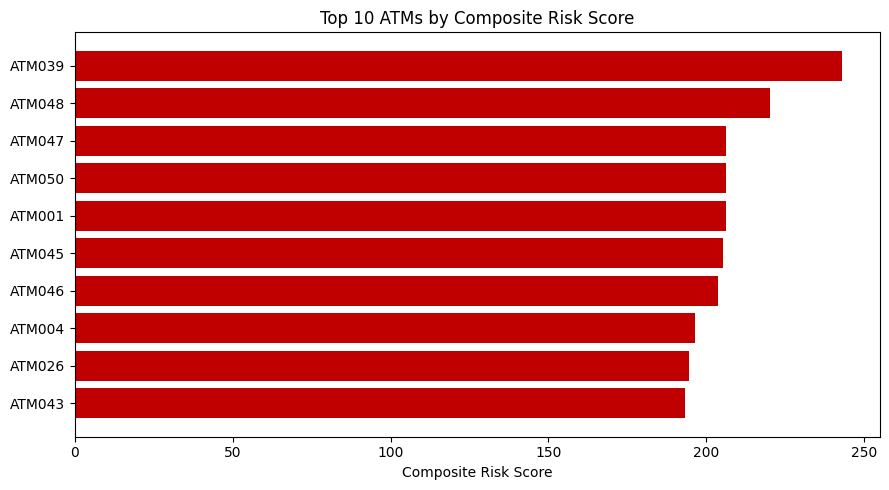

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
top10 = snapshot.head(10)
colors = ['#C00000' if s == 'CRITICAL' else '#ED7D31' for s in top10['risk_status']]
ax.barh(top10['atm_id'][::-1], top10['composite_risk_score'][::-1], color=colors[::-1])
ax.set_xlabel('Composite Risk Score')
ax.set_title('Top 10 ATMs by Composite Risk Score')
plt.tight_layout()
plt.show()


## 8. Tax Season Demand Pattern Analysis

In [11]:
seasonal = df.merge(atm_master[['atm_id', 'location_type', 'tax_service_proximity']], on='atm_id')
seasonal_avg = seasonal.groupby(['location_type', 'season'])['daily_cash_dispensed'].mean().unstack()
baseline_col = seasonal_avg['Baseline']
pct_lift = seasonal_avg.sub(baseline_col, axis=0).div(baseline_col, axis=0).mul(100).round(1)
pct_lift[['Tax Season Peak', 'Tax Season Ramp', 'Holiday']]


season,Tax Season Peak,Tax Season Ramp,Holiday
location_type,,,
Airport,33.5,2.9,6.6
Casino,45.5,4.0,7.0
Hospital,40.9,3.9,8.6
Mall,46.5,12.3,15.1
Office,49.9,0.3,0.9
Retail,69.5,9.4,9.7
Stadium,30.3,5.5,10.2
Tourist,43.0,5.8,14.3
Urban,128.4,10.3,10.8


## 9. Day-of-Week Demand Pattern by Terminal Tier

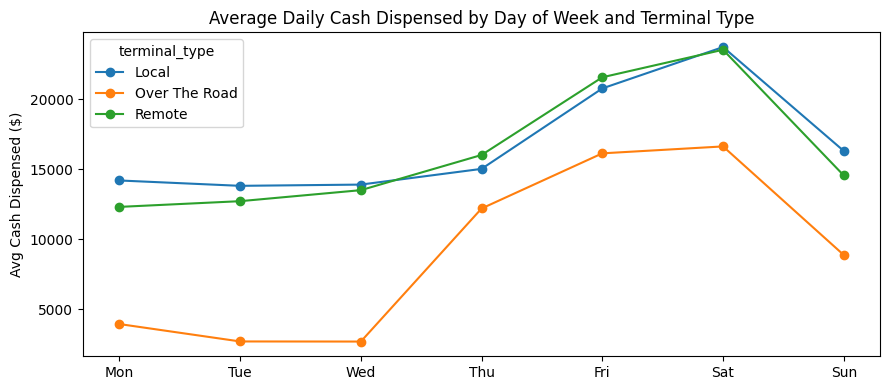

In [12]:
dow_terminal = df.merge(atm_master[['atm_id', 'terminal_type']], on='atm_id')
pivot = dow_terminal.groupby(['terminal_type', 'dow'])['daily_cash_dispensed'].mean().unstack(0)
pivot.index = dow_labels
fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot(ax=ax, marker='o')
ax.set_title('Average Daily Cash Dispensed by Day of Week and Terminal Type')
ax.set_ylabel('Avg Cash Dispensed ($)')
plt.tight_layout()
plt.show()


## 10. Walk-Forward Model Validation

Holdout: **December 2024** (31 days x 50 ATMs = 1,550 candidate predictions).
The forecast for each day uses only information available the day before
(prior balance, burn rate computed through *t-1*) — this is what makes it a
genuine walk-forward validation instead of a lookahead-biased fit.

**Methodology note on scheduled replenishment:** a cash delivery makes the
balance jump *up* day-over-day. That's a dispatch event, not a demand-forecast
failure — this model forecasts organic cash depletion, and predicting the exact
day a truck arrives is a downstream scheduling decision made *from* this
model's output, not an input to it. Accuracy is scored on organic burn days;
the critical-flag classifier uses the same exclusion, since a "miss" on the day
cash was already delivered isn't a real forecasting error.


In [13]:
bt = df.merge(atm_master[['atm_id', 'cash_capacity_dollars', 'cash_tolerance']], on='atm_id')
bt = bt.sort_values(['atm_id', 'transaction_date']).reset_index(drop=True)
bt['rolling_7d_burn'] = bt.groupby('atm_id')['daily_cash_dispensed'].transform(lambda s: s.rolling(7, min_periods=1).mean())
bt['prev_balance'] = bt.groupby('atm_id')['cash_balance_eod'].shift(1)
bt['critical_threshold_pct'] = bt['cash_tolerance'].map(threshold_map)

holdout = bt[bt['transaction_date'] >= '2024-12-01'].copy()
holdout['predicted_balance'] = holdout['prev_balance'] - holdout.groupby('atm_id')['rolling_7d_burn'].shift(1)
holdout = holdout.dropna(subset=['predicted_balance', 'cash_balance_eod'])

holdout['error'] = holdout['cash_balance_eod'] - holdout['predicted_balance']
holdout['abs_error'] = holdout['error'].abs()
holdout['is_refill_day'] = holdout['cash_balance_eod'] > holdout['prev_balance']

burn_days = holdout[~holdout['is_refill_day']]
mae = burn_days['abs_error'].mean()
rmse = np.sqrt((burn_days['error'] ** 2).mean())
nonzero = burn_days[burn_days['cash_balance_eod'] > 50]
mape = (nonzero['abs_error'] / nonzero['cash_balance_eod']).mean() * 100
pct_within_10 = (burn_days['abs_error'] <= 0.10 * burn_days['cash_capacity_dollars']).mean() * 100
pct_within_20 = (burn_days['abs_error'] <= 0.20 * burn_days['cash_capacity_dollars']).mean() * 100

holdout['actual_pct'] = (holdout['cash_balance_eod'] / holdout['cash_capacity_dollars']) * 100
holdout['predicted_pct'] = (holdout['predicted_balance'] / holdout['cash_capacity_dollars']) * 100
holdout['actual_critical'] = holdout['actual_pct'] <= holdout['critical_threshold_pct']
holdout['predicted_critical'] = holdout['predicted_pct'] <= holdout['critical_threshold_pct']

clf = holdout[~holdout['is_refill_day']]
tp = (clf['actual_critical'] & clf['predicted_critical']).sum()
fp = (~clf['actual_critical'] & clf['predicted_critical']).sum()
fn = (clf['actual_critical'] & ~clf['predicted_critical']).sum()
tn = (~clf['actual_critical'] & ~clf['predicted_critical']).sum()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print(f"Holdout predictions (total):   {len(holdout)}")
print(f"Organic burn-day predictions:  {len(burn_days)} (excludes scheduled refill days)")
print(f"MAE:  ${mae:,.0f}/day")
print(f"RMSE: ${rmse:,.0f}/day")
print(f"MAPE: {mape:.1f}%")
print(f"Within 10% of actual: {pct_within_10:.1f}%")
print(f"Within 20% of actual: {pct_within_20:.1f}%")
print(f"Critical flag precision: {precision:.3f}")
print(f"Critical flag recall:    {recall:.3f}")
print(f"F1 score:                {f1:.3f}")
print(f"Confusion matrix -> TP:{tp} FP:{fp} FN:{fn} TN:{tn}")


Holdout predictions (total):   1500
Organic burn-day predictions:  1136 (excludes scheduled refill days)
MAE:  $6,138/day
RMSE: $8,878/day
MAPE: 40.1%
Within 10% of actual: 60.8%
Within 20% of actual: 92.5%
Critical flag precision: 0.982
Critical flag recall:    0.854
F1 score:                0.914
Confusion matrix -> TP:487 FP:9 FN:83 TN:557


## 11. Network Summary (72-Hour Forecast Window)

In [14]:
n_atms = len(snapshot)
n_critical = (snapshot['risk_status'] == 'CRITICAL').sum()
n_otr_critical = ((snapshot['risk_status'] == 'CRITICAL') & (snapshot['terminal_type'] == 'Over The Road')).sum()
n_tax_prox = snapshot['tax_service_proximity'].sum()
revenue_at_risk = snapshot.loc[snapshot['risk_status'] == 'CRITICAL', 'revenue_at_risk_72hr'].sum()

print(f"{n_atms} ATMs monitored across the network")
print(f"{n_critical} flagged CRITICAL within 72 hours")
print(f"{n_otr_critical} Over The Road terminals in critical status")
print(f"{n_tax_prox} tax service proximity machines in the network")
print(f"${revenue_at_risk:,.0f} revenue at risk (72hr, critical ATMs only)")


50 ATMs monitored across the network
36 flagged CRITICAL within 72 hours
10 Over The Road terminals in critical status
5 tax service proximity machines in the network
$706,320 revenue at risk (72hr, critical ATMs only)


---
*Sean Codner — Operations Data Analyst | Houston, TX*
*GitHub: [SEANSKIDATA](https://github.com/SEANSKIDATA) | LinkedIn: [Sean Codner](https://www.linkedin.com/in/sean-codner-aa60822b)*
